# TP FINAL ANALISIS DE DATOS

**Dataset:** Full TMDB Movies Dataset 2024

**Objetivo:** Realizar un Análisis Exploratorio de Datos (EDA) completo y preparar el set de datos para un futuro modelo de Machine Learning supervisado.

## Carga de Librerías y Datos
Importamos las herramientas necesarias vistas en clase para manipulación de datos, visualización y análisis de valores faltantes.

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import kagglehub
from scipy import stats as st
from scipy.stats import describe

pd.options.display.float_format = '{:,.4f}'.format
pd.set_option("display.max_columns", None)

In [140]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/tmdb-movies-dataset-2023-930k-movies")

df = pd.read_csv(path + "/TMDB_movie_dataset_v11.csv", na_values='sin especificar', encoding='ISO-8859-1')
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.3640,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",83.9520,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.4170,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,140.2410,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.5120,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,185000000,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.6430,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.5730,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,https://www.avatar.com/movies/avatar,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.9320,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.7100,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,220000000,https://www.marvel.com/movies/the-avengers,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,98.0820,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


## 2. Exploración y Comprensión de los Datos
Analizamos las dimensiones del dataset, los tipos de variables presentes y un resumen estadístico general para identificar posibles anomalías a simple vista.

In [141]:
# Dimensiones del dataset
filas, columnas = df.shape
print(f"El dataset contiene {filas} observaciones (películas) y {columnas} variables (columnas).")
print("-" * 50)

# Información de tipos de datos
print("Tipos de datos y conteo de no-nulos:")
display(df.info())
print("-" * 50)

# Estadísticas descriptivas de las variables numéricas
print("Resumen estadístico de variables numéricas:")
display(df.describe())

El dataset contiene 1409155 observaciones (películas) y 24 variables (columnas).
--------------------------------------------------
Tipos de datos y conteo de no-nulos:


Task was destroyed but it is pending!
task: <Task pending name='Task-586' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/alan/miniconda3/envs/analisis_datos/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-587' coro=<Kernel.shell_main() running at /home/alan/miniconda3/envs/analisis_datos/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/alan/miniconda3/envs/analisis_datos/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-587' coro=<Kernel.shell_main() running at /home/alan/miniconda3/envs/analisis_datos/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


<class 'pandas.DataFrame'>
RangeIndex: 1409155 entries, 0 to 1409154
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1409155 non-null  int64  
 1   title                 1409137 non-null  str    
 2   vote_average          1409155 non-null  float64
 3   vote_count            1409155 non-null  int64  
 4   status                1409155 non-null  str    
 5   release_date          1098557 non-null  str    
 6   revenue               1409155 non-null  int64  
 7   runtime               1409155 non-null  int64  
 8   adult                 1409155 non-null  bool   
 9   backdrop_path         350819 non-null   str    
 10  budget                1409155 non-null  int64  
 11  homepage              145078 non-null   str    
 12  imdb_id               666022 non-null   str    
 13  original_language     1409155 non-null  str    
 14  original_title        1409137 non-null  str  

None

--------------------------------------------------
Resumen estadístico de variables numéricas:


,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,"1,409,155.0000","1,409,155.0000","1,409,155.0000","1,409,155.0000","1,409,155.0000","1,409,155.0000","1,409,155.0000"
mean,"893,695.7005",1.5643,15.2271,"621,166.4993",44.0886,"236,767.5725",1.0185
std,"474,769.1131",2.8629,286.1557,"19,306,871.4812",60.6756,"5,089,088.4724",6.8297
min,2.0000,0.0000,0.0000,-12.0000,-28.0000,0.0000,0.0000
25%,"491,848.5000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0500
50%,"916,431.0000",0.0000,0.0000,0.0000,16.0000,0.0000,0.6000
75%,"1,309,476.5000",1.0000,1.0000,0.0000,85.0000,0.0000,0.7090
max,"1,678,042.0000",10.0000,"34,495.0000","4,999,999,999.0000","14,400.0000","999,999,999.0000","2,994.3570"


Generando visualizaciones de la Exploración de Datos (EDA)...


<Figure size 1000x400 with 0 Axes>

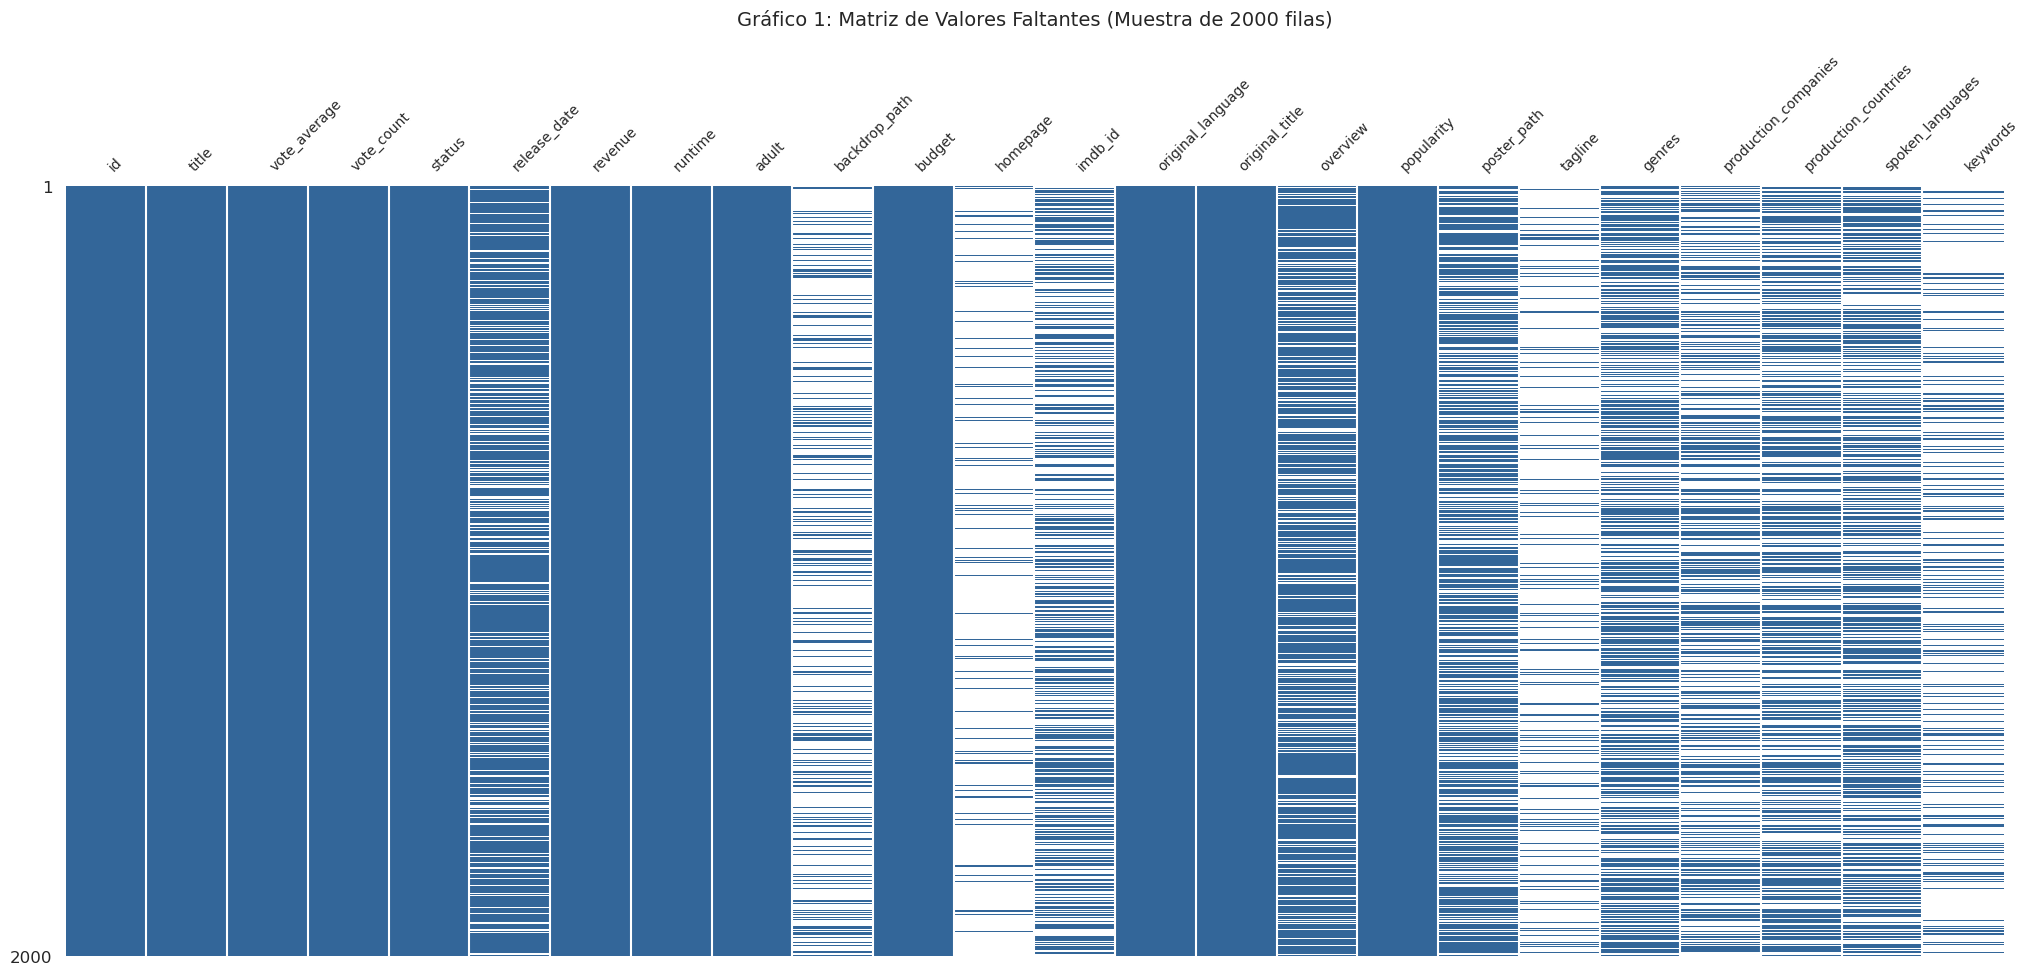

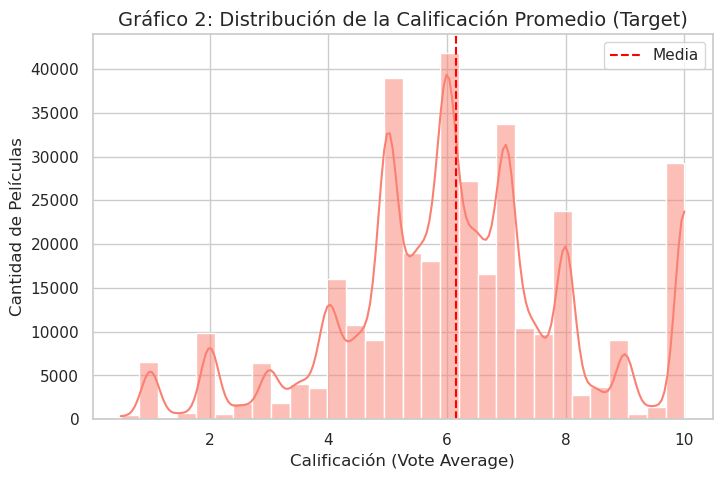

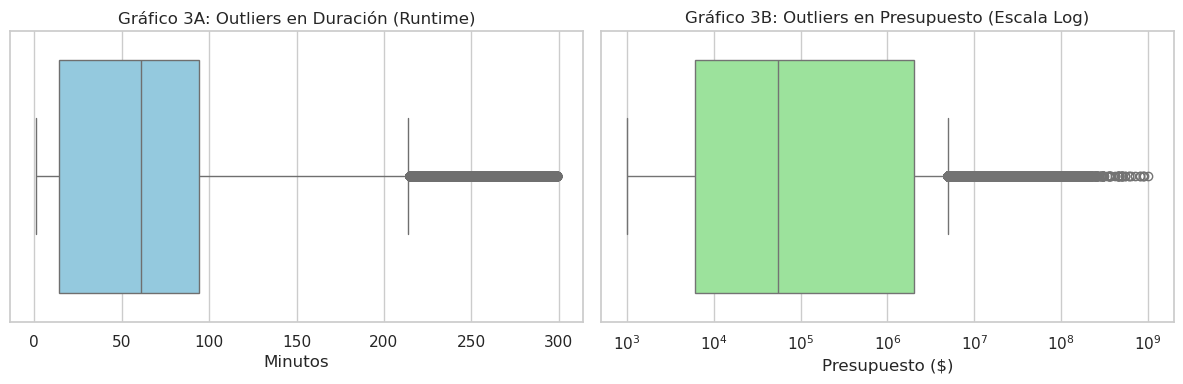

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuramos el estilo visual 
sns.set_theme(style="whitegrid")

print("Generando visualizaciones de la Exploración de Datos (EDA)...")

# --- GRÁFICO 1: Análisis de Valores Faltantes (Nulos) ---
plt.figure(figsize=(10, 4))
msno.matrix(df.sample(2000), sparkline=False, fontsize=10, color=(0.2, 0.4, 0.6))
plt.title("Gráfico 1: Matriz de Valores Faltantes (Muestra de 2000 filas)", fontsize=14, pad=20)
plt.show()

# --- GRÁFICO 2: Distribución de nuestra Variable Target (vote_average) ---
# Filtramos los ceros temporalmente solo para que el gráfico no se deforme
df_viz = df[df['vote_average'] > 0]

plt.figure(figsize=(8, 5))
sns.histplot(data=df_viz, x='vote_average', bins=30, kde=True, color='salmon')
plt.title("Gráfico 2: Distribución de la Calificación Promedio (Target)", fontsize=14)
plt.xlabel("Calificación (Vote Average)")
plt.ylabel("Cantidad de Películas")
plt.axvline(df_viz['vote_average'].mean(), color='red', linestyle='dashed', label='Media')
plt.legend()
plt.show()

# --- GRÁFICO 3: Detección de Outliers (Valores Atípicos) ---
# Filtramos duraciones ilógicas para ver bien la caja
df_outliers = df[(df['runtime'] > 0) & (df['runtime'] < 300)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df_outliers, x='runtime', color='skyblue', ax=axes[0])
axes[0].set_title('Gráfico 3A: Outliers en Duración (Runtime)')
axes[0].set_xlabel('Minutos')

# Usamos escala logarítmica en el presupuesto porque si no, los blockbusters aplastan el gráfico
df_budget = df[df['budget'] > 1000]
sns.boxplot(data=df_budget, x='budget', color='lightgreen', ax=axes[1])
axes[1].set_title('Gráfico 3B: Outliers en Presupuesto (Escala Log)')
axes[1].set_xlabel('Presupuesto ($)')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

### Interpretación de las Visualizaciones:
1. **Gráfico 1 (Faltantes):** Se observa claramente que columnas secundarias como `homepage` o `tagline` están casi en blanco (comportamiento tipo MAR, ligado a producciones pequeñas sin presupuesto para marketing).
2. **Gráfico 2 (Distribución del Target):** La calificación de las películas sigue una distribución casi normal (campana de Gauss), centrada entre los 6 y 7 puntos, lo cual es ideal para un modelo de Regresión.
3. **Gráficos 3A y 3B (Outliers):** Los Boxplots revelan una enorme cantidad de valores atípicos (puntos fuera de los bigotes). En el cine, esto es normal: representan películas excepcionalmente largas o súper producciones (blockbusters). Esto justifica por qué más adelante usaremos la *Mediana* para imputar y el *StandardScaler* para normalizar.

## Análisis de Valores Faltantes
Identificamos la cantidad y el porcentaje de datos faltantes por cada variable.

Variables con valores faltantes:


,Cantidad de Nulos,Porcentaje (%)
homepage,1264077,89.7046
tagline,1213012,86.0808
keywords,1059820,75.2096
backdrop_path,1058336,75.1043
production_companies,808098,57.3463
imdb_id,743133,52.7361
production_countries,680202,48.2702
spoken_languages,653105,46.3473
genres,617756,43.8388
poster_path,499094,35.4180


<Figure size 1000x600 with 0 Axes>

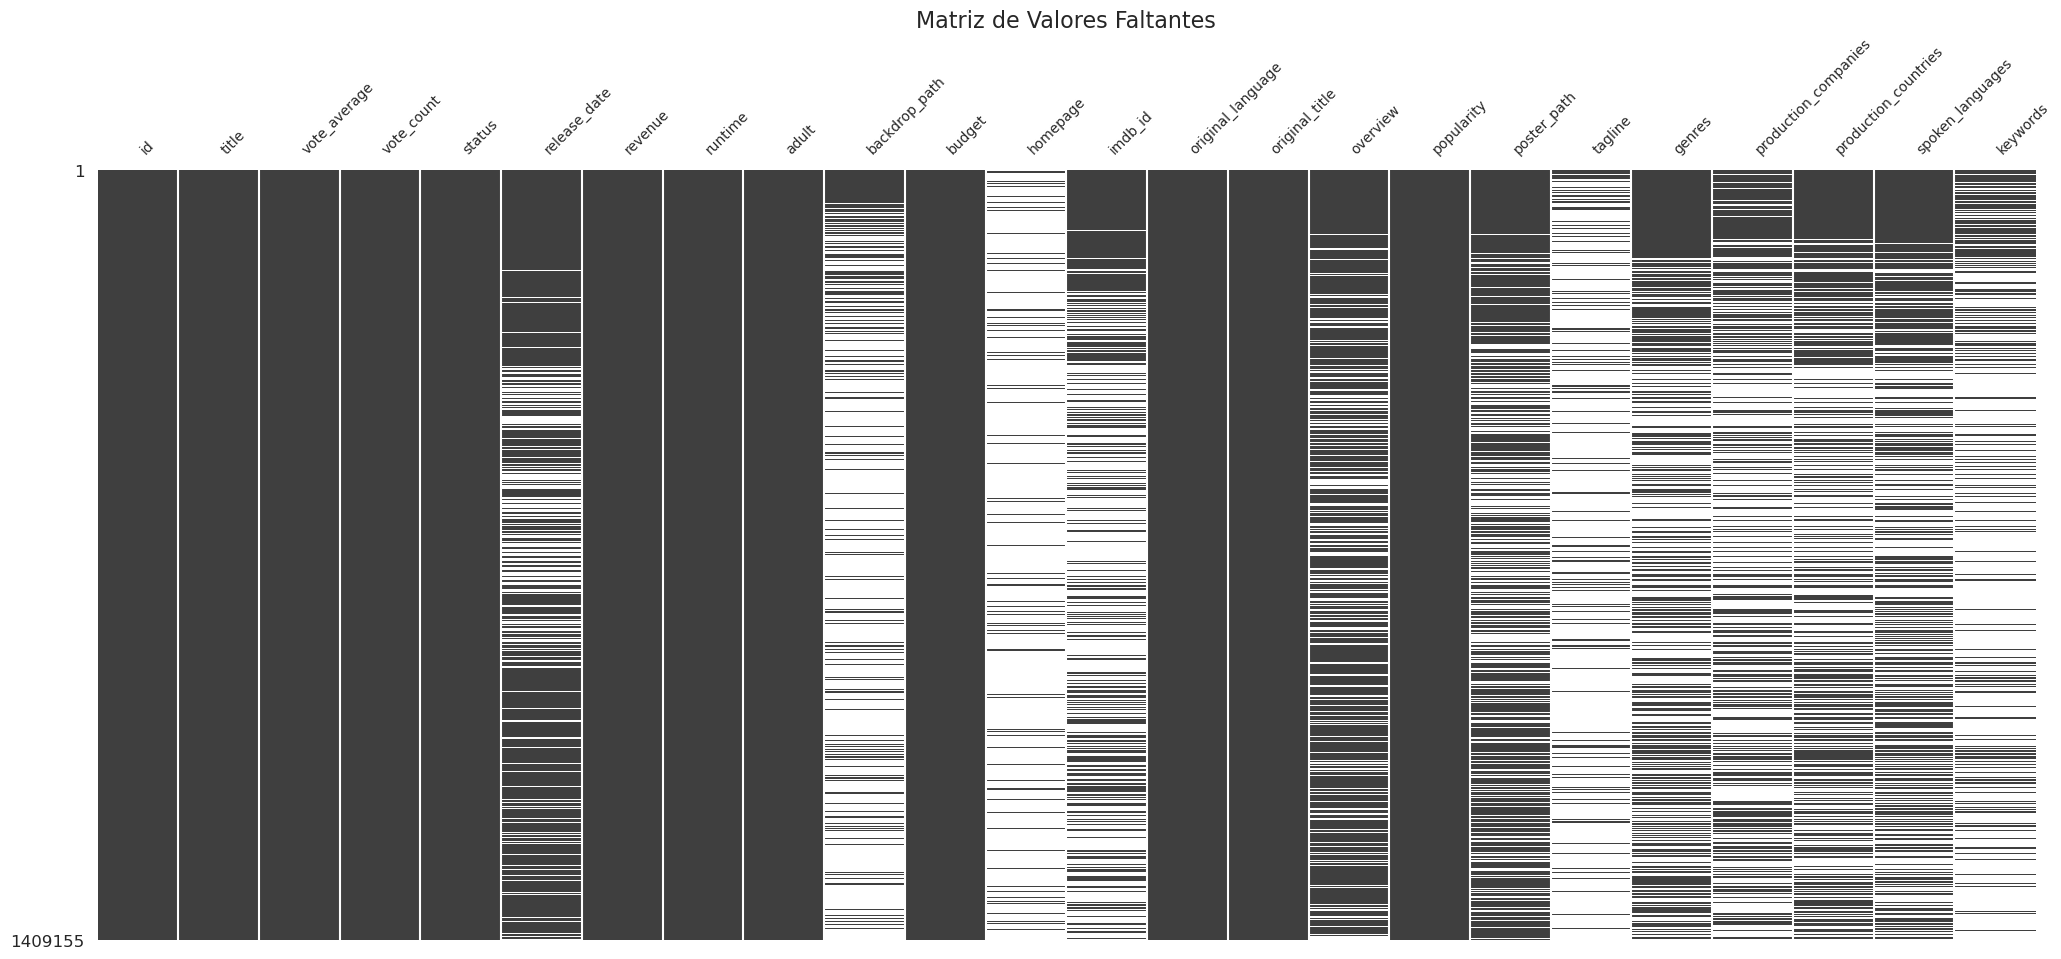

In [143]:
# Cálculo del porcentaje de nulos
nulos_totales = df.isnull().sum()
porcentaje_nulos = (nulos_totales / len(df)) * 100

# Creamos un DataFrame para visualizarlo mejor
df_nulos = pd.DataFrame({
    'Cantidad de Nulos': nulos_totales, 
    'Porcentaje (%)': porcentaje_nulos
})

# Filtramos solo las columnas que tienen nulos y ordenamos de mayor a menor
df_nulos = df_nulos[df_nulos['Porcentaje (%)'] > 0].sort_values(by='Porcentaje (%)', ascending=False)

print("Variables con valores faltantes:")
display(df_nulos)

# Visualización gráfica de los nulos
plt.figure(figsize=(10, 6))
msno.matrix(df, sparkline=False, fontsize=10)
plt.title("Matriz de Valores Faltantes", fontsize=16)
plt.show()

In [144]:
# Eliminamos columnas con exceso de nulos o irrelevantes para Machine Learning
columnas_a_eliminar = ['homepage', 'tagline', 'keywords', 'backdrop_path', 
                       'poster_path', 'imdb_id', 'id', 'original_title', 'overview']

df_limpio = df.drop(columns=columnas_a_eliminar)

# 2. Análisis rápido de posibles variables a predecir (Target)
print("Análisis de ceros en variables clave:")
print(f"Películas con presupuesto (budget) = 0: {(df_limpio['budget'] == 0).sum()} ({(df_limpio['budget'] == 0).sum() / len(df_limpio) * 100:.2f}%)")
print(f"Películas con recaudación (revenue) = 0: {(df_limpio['revenue'] == 0).sum()} ({(df_limpio['revenue'] == 0).sum() / len(df_limpio) * 100:.2f}%)")
print(f"Películas con cero votos (vote_count) = 0: {(df_limpio['vote_count'] == 0).sum()} ({(df_limpio['vote_count'] == 0).sum() / len(df_limpio) * 100:.2f}%)")

print("-" * 50)
print(f"Nuevas dimensiones del dataset: {df_limpio.shape[0]} filas y {df_limpio.shape[1]} columnas.")
display(df_limpio.head(3))

Análisis de ceros en variables clave:
Películas con presupuesto (budget) = 0: 1328830 (94.30%)
Películas con recaudación (revenue) = 0: 1385070 (98.29%)
Películas con cero votos (vote_count) = 0: 1050759 (74.57%)
--------------------------------------------------
Nuevas dimensiones del dataset: 1409155 filas y 15 columnas.


,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,original_language,popularity,genres,production_companies,production_countries,spoken_languages
0,Inception,8.3640,34495,Released,2010-07-15,825532764,148,False,160000000,en,83.9520,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili"
1,Interstellar,8.4170,32571,Released,2014-11-05,701729206,169,False,165000000,en,140.2410,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English
2,The Dark Knight,8.5120,30619,Released,2008-07-16,1004558444,152,False,185000000,en,130.6430,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin"


## Definición del Problema de Machine Learning

**Problema planteado:** Aprendizaje Supervisado - Regresión.

**Variable Target:** `vote_average` (Calificación promedio de la película).

**Objetivo:** Predecir qué calificación le dará el público a una película en base a sus características (duración, géneros, popularidad, etc.).

*Nota de limpieza:* Para que el modelo aprenda correctamente, primero debemos filtrar aquellas películas que tienen 0 votos o una duración de 0 minutos, ya que representan ruido (datos no registrados).

In [145]:
from sklearn.model_selection import train_test_split

# 1. Filtramos películas que no tienen votos suficientes o tienen duración cero
df_reg = df_limpio[(df_limpio['vote_count'] > 10) & (df_limpio['runtime'] > 0)].copy()

# 2. Eliminamos columnas de texto complejo que no sirven directamente para matematicas
columnas_complejas = ['genres', 'production_companies', 'production_countries', 'spoken_languages', 'title']
df_reg = df_reg.drop(columns=columnas_complejas, errors='ignore')

# 3. Definimos nuestras variables predictoras (X) y nuestro Target (y)
X = df_reg.drop(columns=['vote_average'])
y = df_reg['vote_average']

# 4. Realizamos el Split (80% para entrenar, 20% para testear)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de Entrenamiento (Train): {X_train.shape[0]} películas.")
print(f"Set de Prueba (Test): {X_test.shape[0]} películas.")

Set de Entrenamiento (Train): 58414 películas.
Set de Prueba (Test): 14604 películas.


### Preprocesamiento - Imputación y Escalado
Siguiendo las buenas prácticas, el tratamiento de datos se ajusta **solo** sobre el set de entrenamiento (`Train`) y luego se aplica al de prueba (`Test`).
1. **Imputación:** Rellenamos los valores nulos numéricos con la **mediana** (es más robusta ante los outliers como las superproducciones) y los categóricos con la **moda**.
2. **Escalado:** Aplicamos `StandardScaler` a las variables numéricas para estandarizarlas, ya que variables como el presupuesto y la popularidad manejan escalas muy distintas.

In [146]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# Separamos columnas numéricas y categóricas
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# --- IMPUTACIÓN ---
# Numéricas 
imputer_num = SimpleImputer(strategy='median')
X_train[num_cols] = imputer_num.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer_num.transform(X_test[num_cols])

# Categóricas 
for col in cat_cols:
    # Calculamos la moda usando solo los datos de Train
    moda = X_train[col].mode()[0] 
    
    # Rellenamos los vacíos
    X_train[col] = X_train[col].fillna(moda)
    X_test[col] = X_test[col].fillna(moda)

# --- ESCALADO ---
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Valores faltantes imputados correctamente.")
print("Variables numéricas escaladas (StandardScaler).")
display(X_train[num_cols].head(3))

Valores faltantes imputados correctamente.
Variables numéricas escaladas (StandardScaler).


,vote_count,revenue,runtime,budget,popularity
56464,-0.2159,-0.1520,0.5295,-0.2177,0.1542
60937,-0.2175,-0.1520,-0.1377,-0.2177,-0.2161
69489,-0.2191,-0.1520,-0.0507,-0.2177,-0.2409


###  FEATURE ENGINEERING: Creación de Nuevos Features
Creamos un nuevo feature llamado 'presupuesto_por_minuto'
Justificación: Se genera el ratio 'presupuesto por minuto' para normalizar la inversión financiera respecto a la extensión de la obra, permitiendo comparar la densidad de producción de manera equitativa entre cortometrajes y largometrajes.


In [147]:

X_train['presupuesto_por_minuto'] = X_train['budget'] / (X_train['runtime'] + 1) # +1 evita división por cero
X_test['presupuesto_por_minuto'] = X_test['budget'] / (X_test['runtime'] + 1)

# --- SELECCIÓN DE FEATURES ---
# Justificación: Eliminamos 'popularity' y 'vote_count' temporalmente porque, al ocurrir 
# DESPUÉS del estreno, incluirlas para predecir el puntaje generaría Target Leakage (fuga de información).
X_train = X_train.drop(columns=['popularity', 'vote_count'], errors='ignore')
X_test = X_test.drop(columns=['popularity', 'vote_count'], errors='ignore')

print("Feature nuevo creado y selección por filtros aplicada para evitar Target Leakage.")

Feature nuevo creado y selección por filtros aplicada para evitar Target Leakage.


In [148]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# --- ONE-HOT ENCODING ---
# 1. Simplificamos la columna de idiomas (dejamos los más comunes y el resto pasa a ser 'Other')
# Esto evita crear cientos de columnas innecesarias
top_idiomas = X_train['original_language'].value_counts().head(4).index
X_train['original_language'] = X_train['original_language'].apply(lambda x: x if x in top_idiomas else 'Other')
X_test['original_language'] = X_test['original_language'].apply(lambda x: x if x in top_idiomas else 'Other')

# 2. Aplicamos el Encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Entrenamos y transformamos Train
encoded_train = encoder.fit_transform(X_train[['original_language']])
nombres_cols = encoder.get_feature_names_out(['original_language'])
df_encoded_train = pd.DataFrame(encoded_train, columns=nombres_cols, index=X_train.index)

# Transformamos Test
encoded_test = encoder.transform(X_test[['original_language']])
df_encoded_test = pd.DataFrame(encoded_test, columns=nombres_cols, index=X_test.index)

# Unimos al dataset original y borramos la columna de texto original
X_train = pd.concat([X_train.drop(columns=['original_language']), df_encoded_train], axis=1)
X_test = pd.concat([X_test.drop(columns=['original_language']), df_encoded_test], axis=1)

print("One-Hot Encoding completado.el dataset es ahora 100% numérico")
print(f"Nuevas dimensiones de Train: {X_train.shape}")

One-Hot Encoding completado.el dataset es ahora 100% numérico
Nuevas dimensiones de Train: (58414, 12)


Discretización aplicada correctamente a la variable 'budget'.


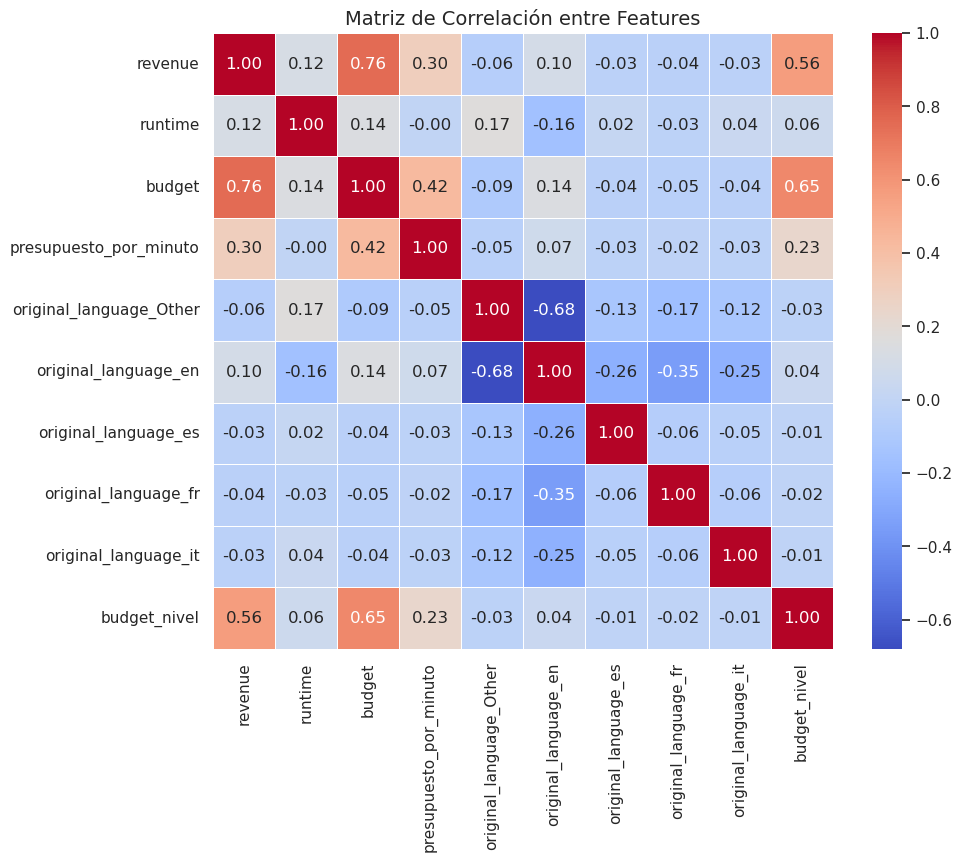

Relaciones evaluadas. Matriz de correlación generada.


In [153]:
from sklearn.preprocessing import KBinsDiscretizer
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

#  DISCRETIZACION 
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform', subsample=None)
X_train['budget_nivel'] = discretizer.fit_transform(X_train[['budget']])
X_test['budget_nivel'] = discretizer.transform(X_test[['budget']])

print("Discretización aplicada correctamente a la variable 'budget'.")

#  EVALUAR RELACIONES (MATRIZ DE CORRELACIÓN) 
plt.figure(figsize=(10, 8))
matriz_corr = X_train.select_dtypes(include=[np.number]).corr()

# Dibujamos el Heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación entre Features', fontsize=14)
plt.show()

print("Relaciones evaluadas. Matriz de correlación generada.")

La matriz de correlación muestra una relación positiva alta entre budget y revenue (0.76), lo que sugiere que películas con mayor presupuesto tienden a presentar mayor recaudación. Asimismo, budget_nivel se correlaciona fuertemente con budget (0.65). Por otro lado, runtime presenta correlaciones bajas con el resto de features, indicando un aporte más independiente. Las variables codificadas de original_language muestran correlaciones negativas entre sí debido a que representan categorías mutuamente excluyentes. En conjunto, la matriz evidencia cierta redundancia entre variables derivadas del presupuesto, lo que justifica el uso de técnicas de reducción de dimensionalidad como PCA.

In [154]:
from sklearn.decomposition import PCA
import numpy as np

# 1. Filtro de seguridad: Nos aseguramos de pasarle al PCA SOLO columnas numéricas
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# 2. Aplicamos PCA (reteniendo el 95% de la varianza)
pca = PCA(n_components=0.95)

# Entrenamos y transformamos con Train
X_train_pca = pca.fit_transform(X_train_numeric)

# Solo transformamos Test
X_test_pca = pca.transform(X_test_numeric)

print("PCA aplicado exitosamente.")
print(f"Pasamos de tener {X_train_numeric.shape[1]} columnas originales a solo {X_train_pca.shape[1]} componentes principales.")

PCA aplicado exitosamente.
Pasamos de tener 10 columnas originales a solo 5 componentes principales.


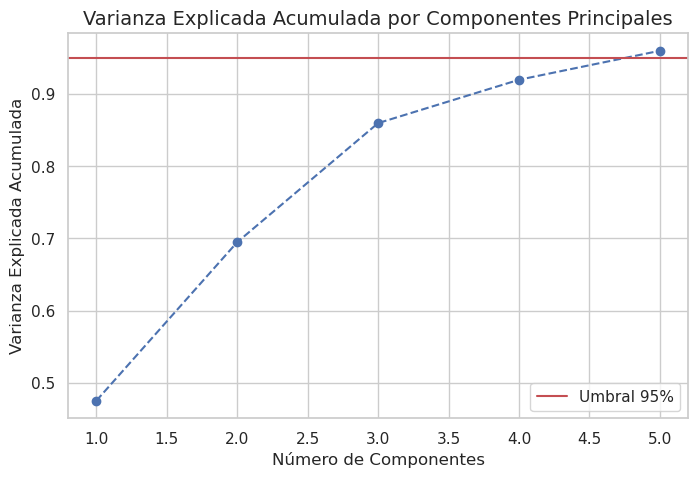

Muestra de los datos transformados (Primeras 5 filas):
[[-0.21940396 -0.15869507  0.41928594  0.57639763 -0.17634507]
 [-0.4070881   0.06556879  0.10081764 -0.87891469  0.14273417]
 [-0.36968576  0.06665807  0.05810851 -0.35592107  0.03460668]
 [-0.38629122  0.13940741 -0.28570587  0.44374273 -0.11228771]
 [-0.19257932  1.48048696 -2.06857728  0.05377398 -0.00336002]]


In [155]:
import matplotlib.pyplot as plt
import numpy as np

# Calculamos la varianza explicada acumulada
varianza_explicada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_explicada) + 1), varianza_explicada, marker='o', linestyle='--', color='b')
plt.title('Varianza Explicada Acumulada por Componentes Principales', fontsize=14)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.axhline(y=0.95, color='r', linestyle='-', label='Umbral 95%')
plt.grid(True)
plt.legend()
plt.show()

# Mostramos las primeras filas de los datos transformados
print("Muestra de los datos transformados (Primeras 5 filas):")
print(X_train_pca[:5])

## Conclusiones Finales y Evaluación de la Reducción de Dimensionalidad

Tras completar el flujo de trabajo de Análisis de Datos sobre el dataset de TMDB, se obtuvieron las siguientes conclusiones:

1. **Efectividad de la Reducción:** Se logró comprimir la información de 10 variables originales en solo 5 componentes principales, reteniendo el **95% de la varianza total**. Esto simplifica enormemente la complejidad matemática para el futuro modelo de regresión.
2. **Ventajas:**
    * **Eliminación de redundancia:** El PCA eliminó la correlación entre variables (como la que existía entre presupuesto y nuestra nueva feature de presupuesto por minuto).
    * **Eficiencia computacional:** Un modelo entrenado con 5 dimensiones será mucho más rápido y consumirá menos memoria que uno con las variables originales.
    * **Limpieza de ruido:** Al descartar el 5% de la varianza restante, es probable que estemos eliminando fluctuaciones aleatorias que no aportan a la predicción del puntaje.
3. **Desventajas:**
    * **Pérdida de Interpretabilidad:** Esta es la principal contra. Al usar PCA, los "componentes" son combinaciones matemáticas. Ya no podemos decir fácilmente "si sube el presupuesto 1 dólar, el puntaje sube X puntos", porque las variables originales se mezclaron.
4. **Estado del Dataset:** El set de datos se entrega 100% numérico, escalado, sin valores faltantes y con una estructura optimizada, cumpliendo con todos los requisitos para ser utilizado en un entrenamiento de Machine Learning supervisado